# Global Tech Jobs — Cross-Country Skills Analysis

**Sources:**
- `data/VN_data/vn_jobs_final.csv` — Vietnam
- `data/SGP_data/sg_jobs_final.csv` — Singapore
- `data/UK_data/uk_jobs_final.csv` — United Kingdom
- `data/US_data/us_jobs_final.csv` — United States

### Sections
1. Dataset Overview
2. Top Hard Skills by Country — Mention Rate Heatmap
3. Most Essential Skills — Global
4. Country-Exclusive Skills
5. Hard Skills by Category — Cross-Country Comparison
6. Skill Vocabulary Overlap (Jaccard)
7. Skill Gap — Where Countries Differ Most
8. Soft Skills by Country
9. Category Signature Skills — Cross-Country

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

COLORS = {
    'Vietnam':       '#e74c3c',
    'Singapore':     '#3498db',
    'UK':            '#2ecc71',
    'United States': '#9b59b6',
}

all_df = pd.read_csv('data/all_jobs_final.csv', encoding='utf-8-sig', dtype={'job_id': str})
dfs = {country: grp.reset_index(drop=True)
       for country, grp in all_df.groupby('country')}

print(f'Loaded: {len(all_df):,} jobs across {len(dfs)} countries')
for c, d in dfs.items():
    print(f'  {c}: {len(d):,} jobs')

Loaded: 6,071 jobs across 4 countries
  Singapore: 1,445 jobs
  UK: 1,637 jobs
  United States: 2,007 jobs
  Vietnam: 982 jobs


In [13]:
def parse_skills(series, lowercase=True):
    out = []
    for cell in series.dropna():
        for s in str(cell).split(','):
            s = s.strip().lower() if lowercase else s.strip()
            if s:
                out.append(s)
    return out

def skill_freq(series, lowercase=True):
    return Counter(parse_skills(series, lowercase))

print(f'Global hard skill mentions : {len(parse_skills(all_df["hard_skills"])):,}')
print(f'Global unique hard skills  : {len(set(parse_skills(all_df["hard_skills"]))):,}')
print(f'Global soft skill mentions : {len(parse_skills(all_df["soft_skills"])):,}')

Global hard skill mentions : 113,445
Global unique hard skills  : 16,775
Global soft skill mentions : 29,266


---
## 1. Dataset Overview

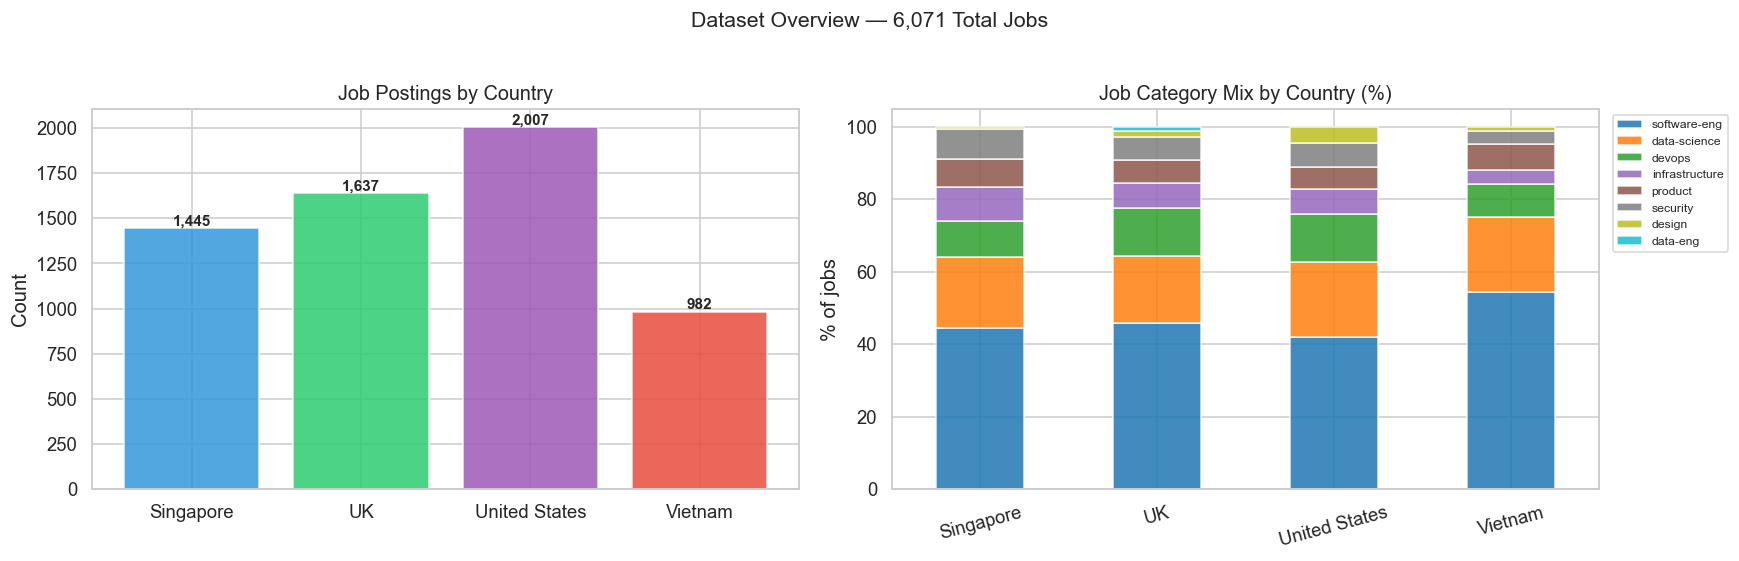

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Jobs per country
counts = {c: len(d) for c, d in dfs.items()}
bars = axes[0].bar(list(counts.keys()), list(counts.values()),
                   color=[COLORS[c] for c in counts], alpha=0.85, edgecolor='white')
axes[0].set_title('Job Postings by Country', fontsize=13)
axes[0].set_ylabel('Count')
for bar, v in zip(bars, counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 f'{v:,}', ha='center', fontsize=10, fontweight='bold')

# Category mix (stacked %)
top_cats = all_df['job_category'].value_counts().head(8).index.tolist()
cat_pct = {}
for country, d in dfs.items():
    total = len(d)
    cat_pct[country] = {cat: 100 * len(d[d['job_category'] == cat]) / total for cat in top_cats}
cat_pct_df = pd.DataFrame(cat_pct).T
cat_pct_df.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab10', alpha=0.85)
axes[1].set_title('Job Category Mix by Country (%)', fontsize=13)
axes[1].set_ylabel('% of jobs')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle(f'Dataset Overview — {len(all_df):,} Total Jobs', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Top Hard Skills by Country — Mention Rate Heatmap

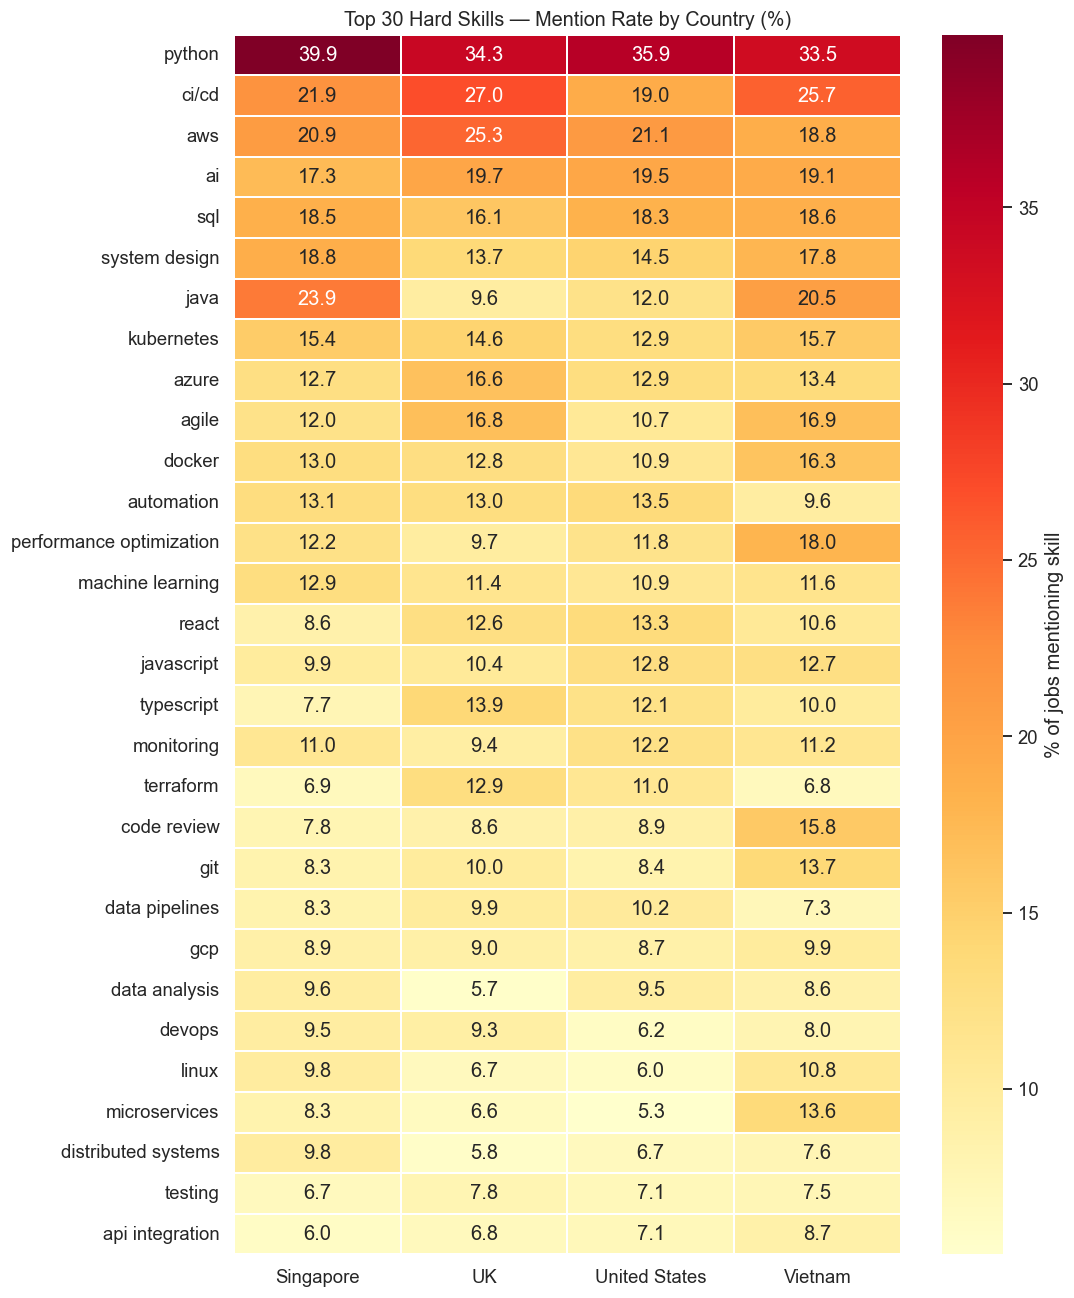

In [15]:
# Mention rate = % of jobs in that country that list the skill
global_top30 = [s for s, _ in Counter(parse_skills(all_df['hard_skills'])).most_common(30)]

hm_data = {}
for country, d in dfs.items():
    freq = skill_freq(d['hard_skills'])
    total = len(d)
    hm_data[country] = {skill: round(100 * freq.get(skill, 0) / total, 1) for skill in global_top30}

hm_df = pd.DataFrame(hm_data, index=global_top30)  # skills x countries

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(hm_df, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.3, cbar_kws={'label': '% of jobs mentioning skill'})
ax.set_title('Top 30 Hard Skills — Mention Rate by Country (%)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Most Essential Skills — Global

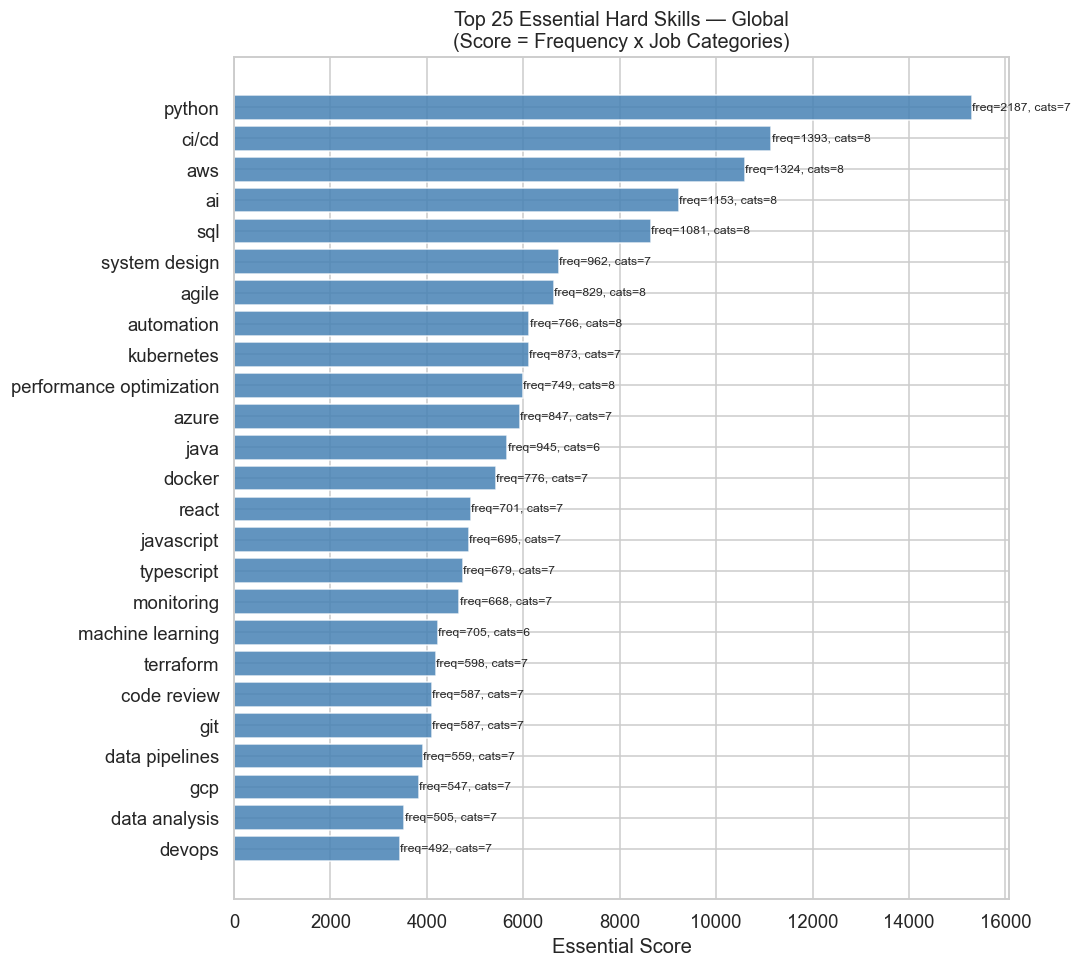

                   skill  frequency  n_categories  essential_score
                  python       2187             7            15309
                   ci/cd       1393             8            11144
                     aws       1324             8            10592
                      ai       1153             8             9224
                     sql       1081             8             8648
           system design        962             7             6734
                   agile        829             8             6632
              automation        766             8             6128
              kubernetes        873             7             6111
performance optimization        749             8             5992
                   azure        847             7             5929
                    java        945             6             5670
                  docker        776             7             5432
                   react        701             7             

In [16]:
# Essential score = frequency x number of distinct job categories the skill appears in
skill_cats = {}
for _, row in all_df.iterrows():
    cat = str(row.get('job_category', ''))
    for skill in str(row.get('hard_skills', '')).split(','):
        skill = skill.strip().lower()
        if skill:
            skill_cats.setdefault(skill, set()).add(cat)

global_freq = Counter(parse_skills(all_df['hard_skills']))
ess_rows = []
for skill, freq in global_freq.items():
    if freq < 20:
        continue
    n_cats = len(skill_cats.get(skill, set()))
    ess_rows.append({
        'skill': skill,
        'frequency': freq,
        'n_categories': n_cats,
        'essential_score': freq * n_cats,
    })

ess_df = (pd.DataFrame(ess_rows)
            .sort_values('essential_score', ascending=False)
            .head(25)
            .reset_index(drop=True))
plot_df = ess_df.sort_values('essential_score', ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(plot_df['skill'], plot_df['essential_score'], color='steelblue', alpha=0.85)
ax.set_title('Top 25 Essential Hard Skills — Global\n(Score = Frequency x Job Categories)', fontsize=13)
ax.set_xlabel('Essential Score')
for bar, freq, ncat in zip(bars, plot_df['frequency'], plot_df['n_categories']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'freq={freq}, cats={ncat}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print(ess_df[['skill', 'frequency', 'n_categories', 'essential_score']].to_string(index=False))

---
## 4. Country-Exclusive Skills

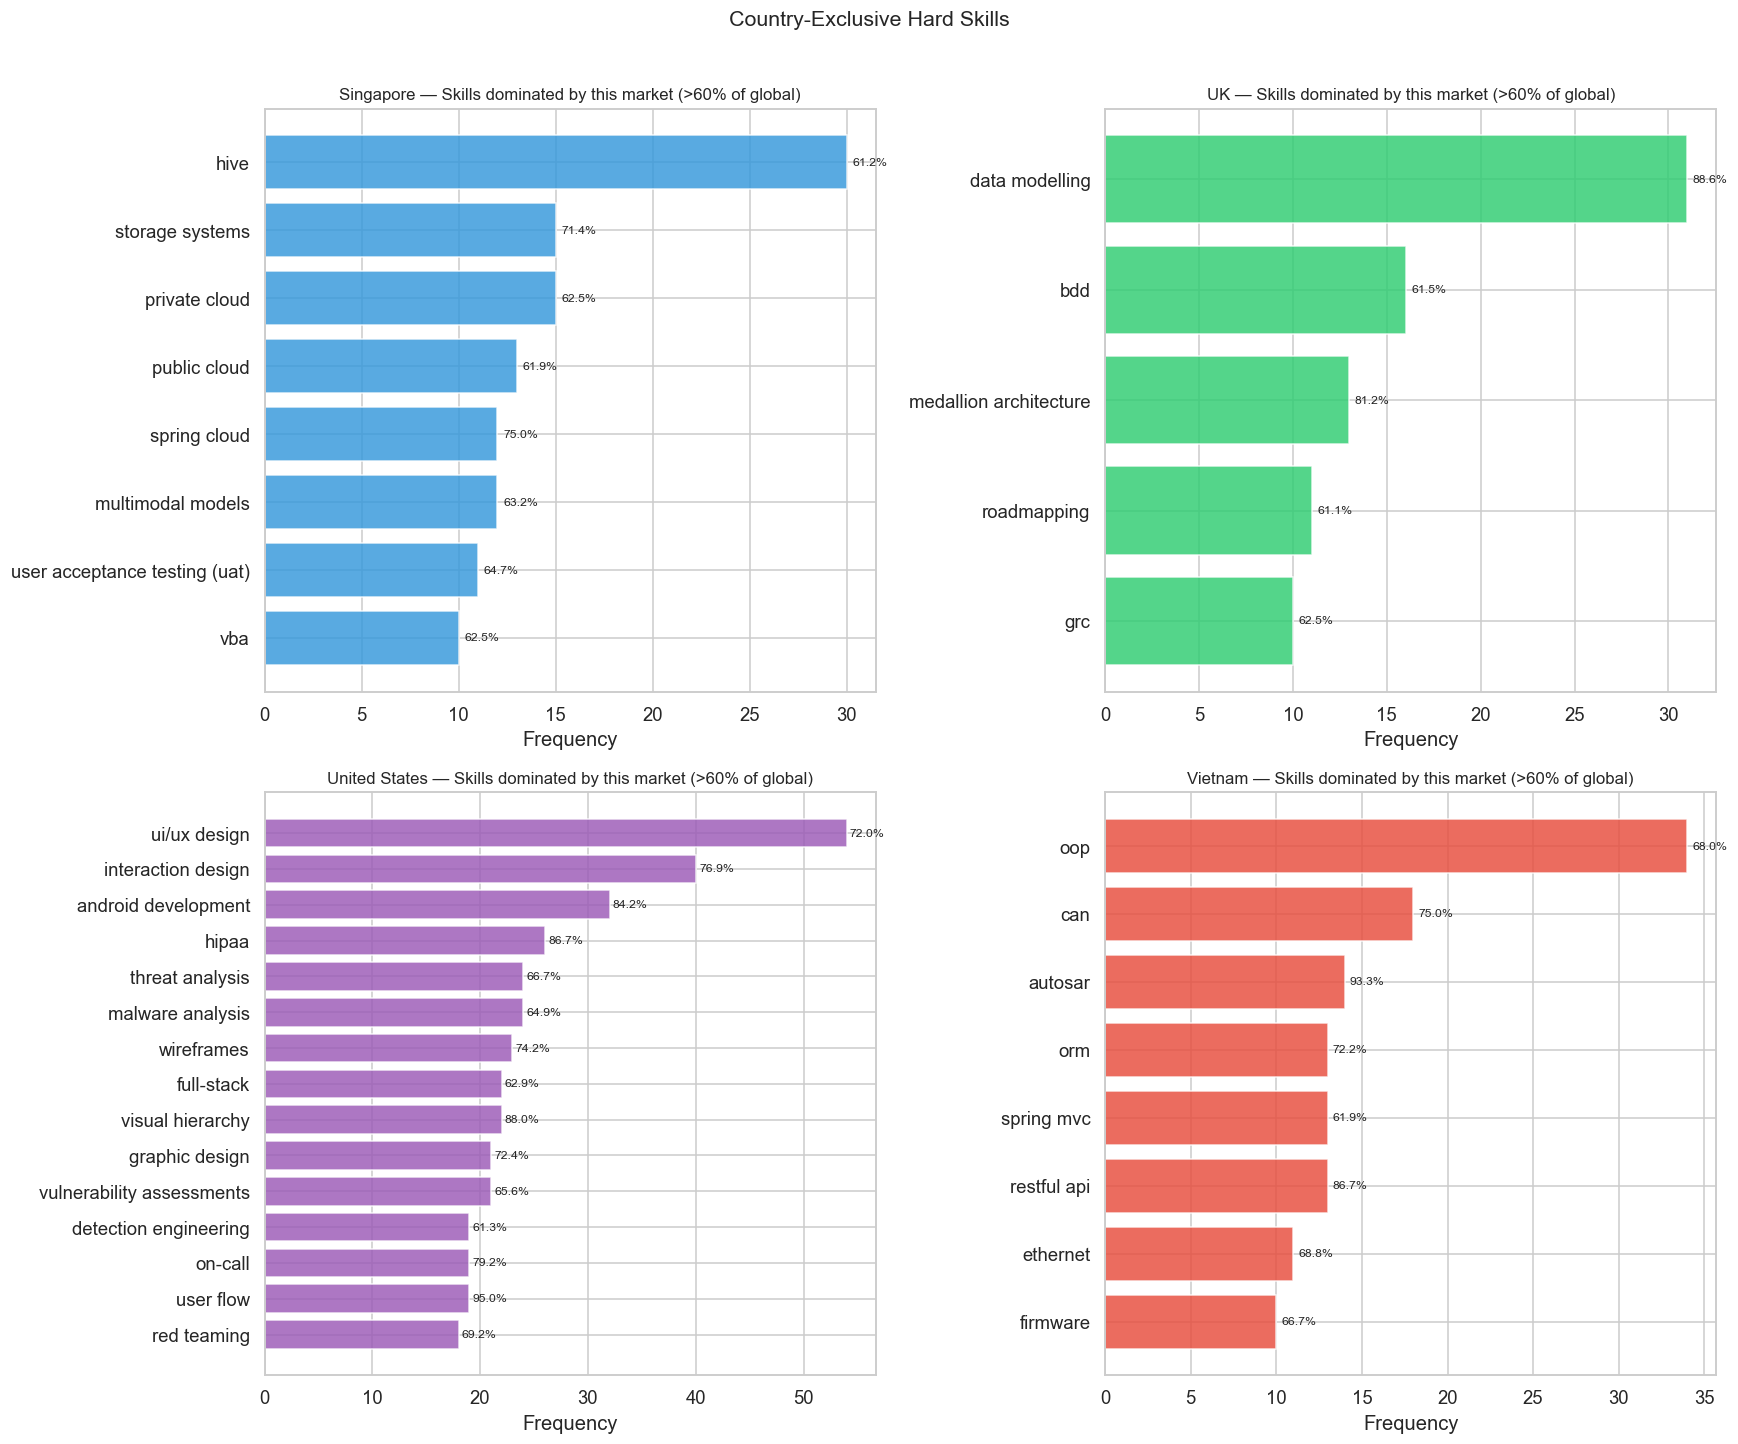

In [17]:
# Skills where >= 60% of global mentions come from one country
global_freq   = Counter(parse_skills(all_df['hard_skills']))
country_freqs = {c: skill_freq(d['hard_skills']) for c, d in dfs.items()}

THRESHOLD = 0.60
MIN_FREQ  = 15

exclusive = {c: [] for c in dfs}
for skill, total in global_freq.items():
    if total < MIN_FREQ:
        continue
    for country in dfs:
        share = country_freqs[country].get(skill, 0) / total
        if share >= THRESHOLD:
            exclusive[country].append({
                'skill':     skill,
                'count':     country_freqs[country][skill],
                'share_pct': round(share * 100, 1),
            })

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
axes = axes.flatten()

for i, (country, skills) in enumerate(exclusive.items()):
    top = sorted(skills, key=lambda x: x['count'], reverse=True)[:15]
    ax  = axes[i]
    if not top:
        ax.text(0.5, 0.5, 'No exclusive skills found', ha='center', va='center', fontsize=12)
        ax.set_title(country)
        continue
    names  = [s['skill']     for s in top][::-1]
    counts = [s['count']     for s in top][::-1]
    shares = [s['share_pct'] for s in top][::-1]
    ax.barh(names, counts, color=COLORS[country], alpha=0.82)
    ax.set_title(f'{country} — Skills dominated by this market (>{int(THRESHOLD*100)}% of global)', fontsize=11)
    ax.set_xlabel('Frequency')
    for j, (c, sh) in enumerate(zip(counts, shares)):
        ax.text(c + 0.3, j, f'{sh}%', va='center', fontsize=8)

plt.suptitle('Country-Exclusive Hard Skills', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Hard Skills by Category — Cross-Country Comparison

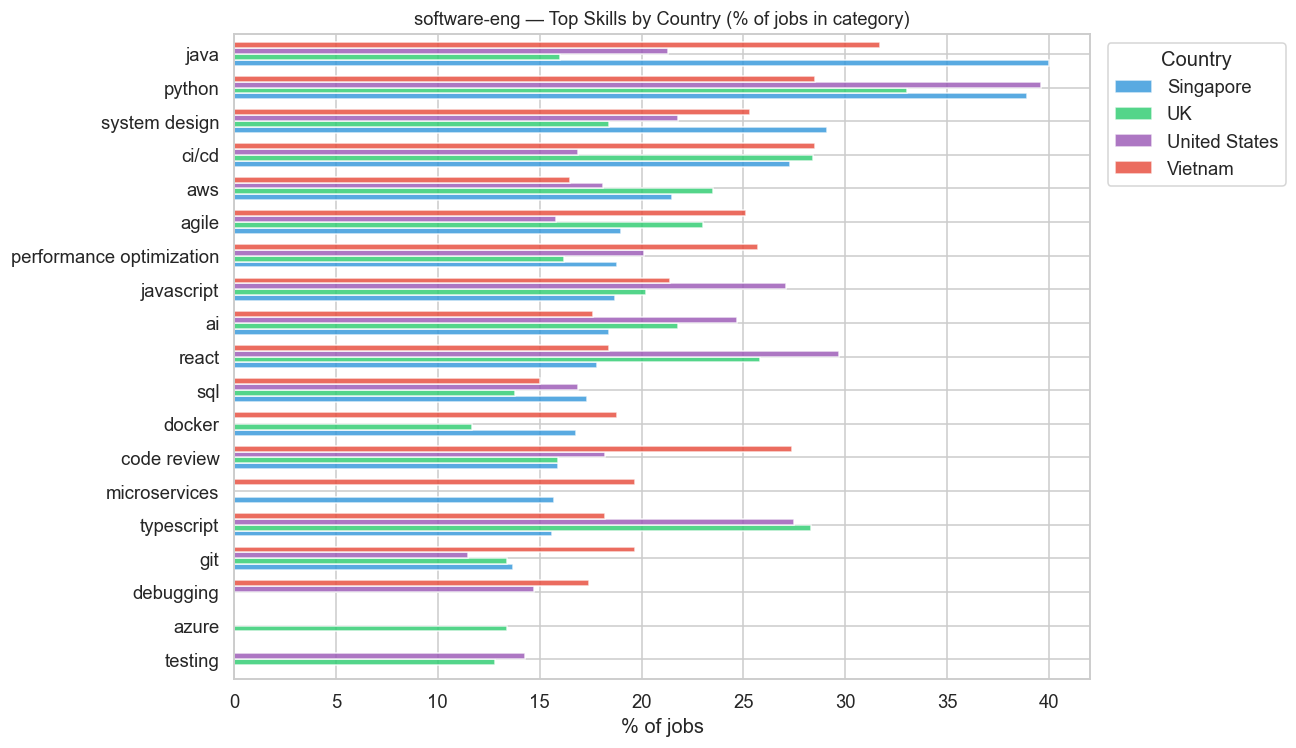

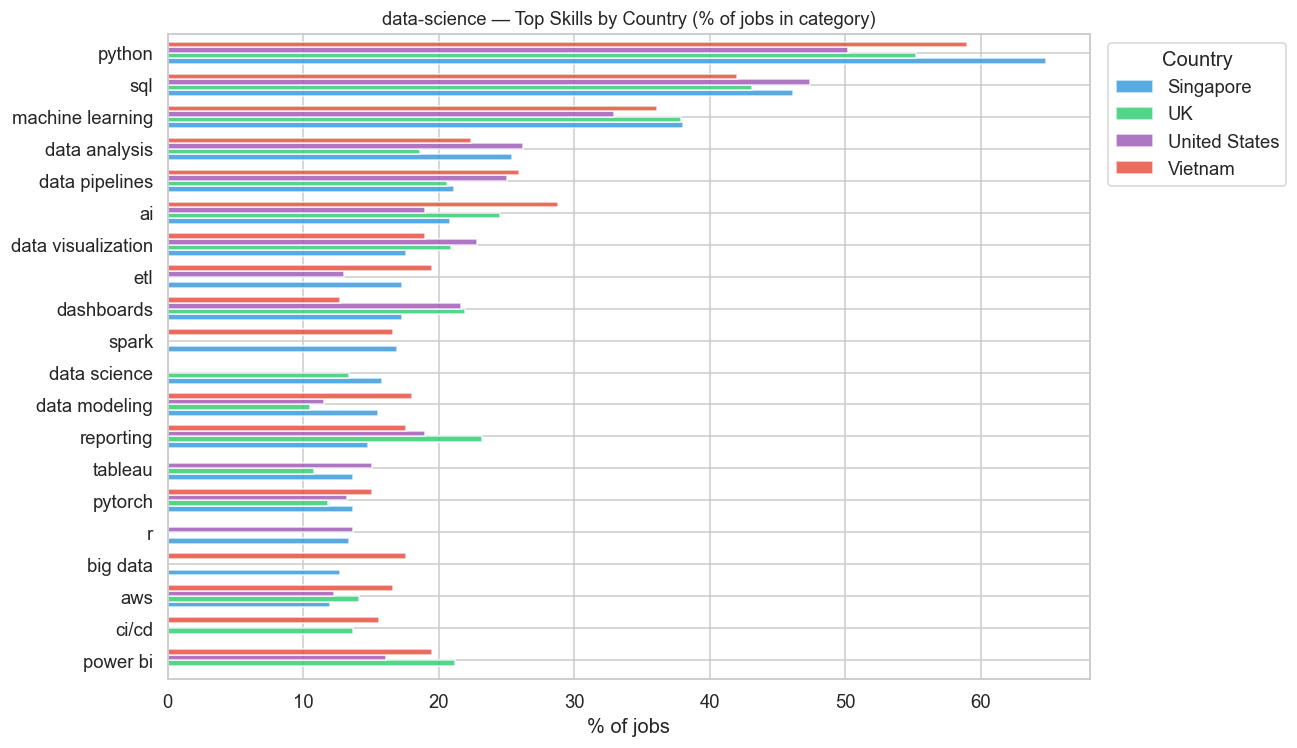

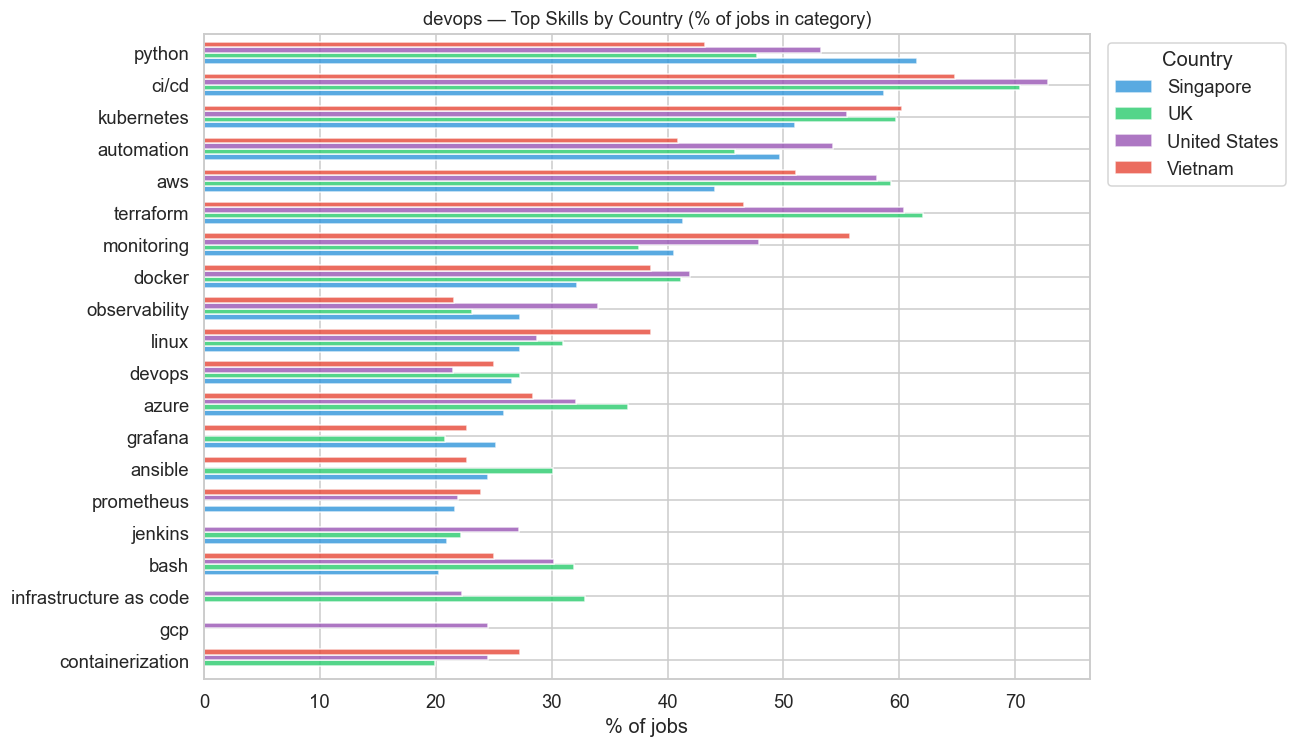

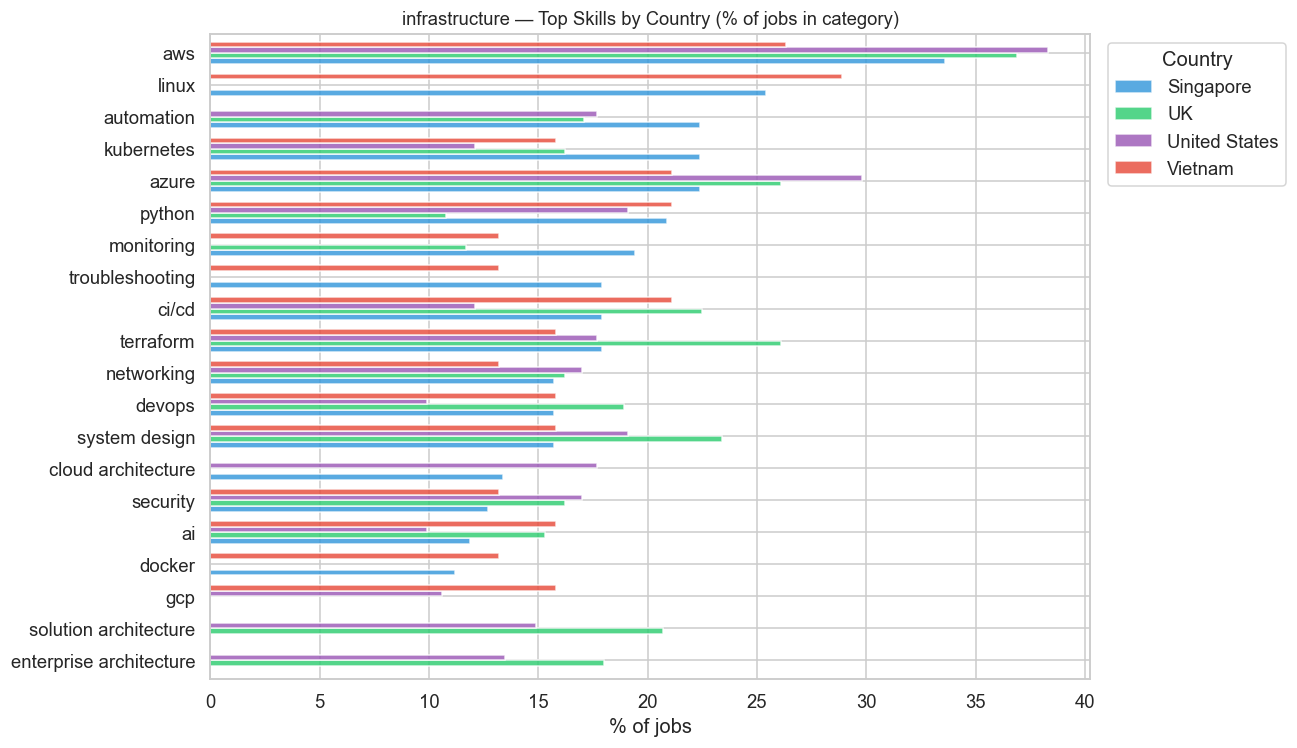

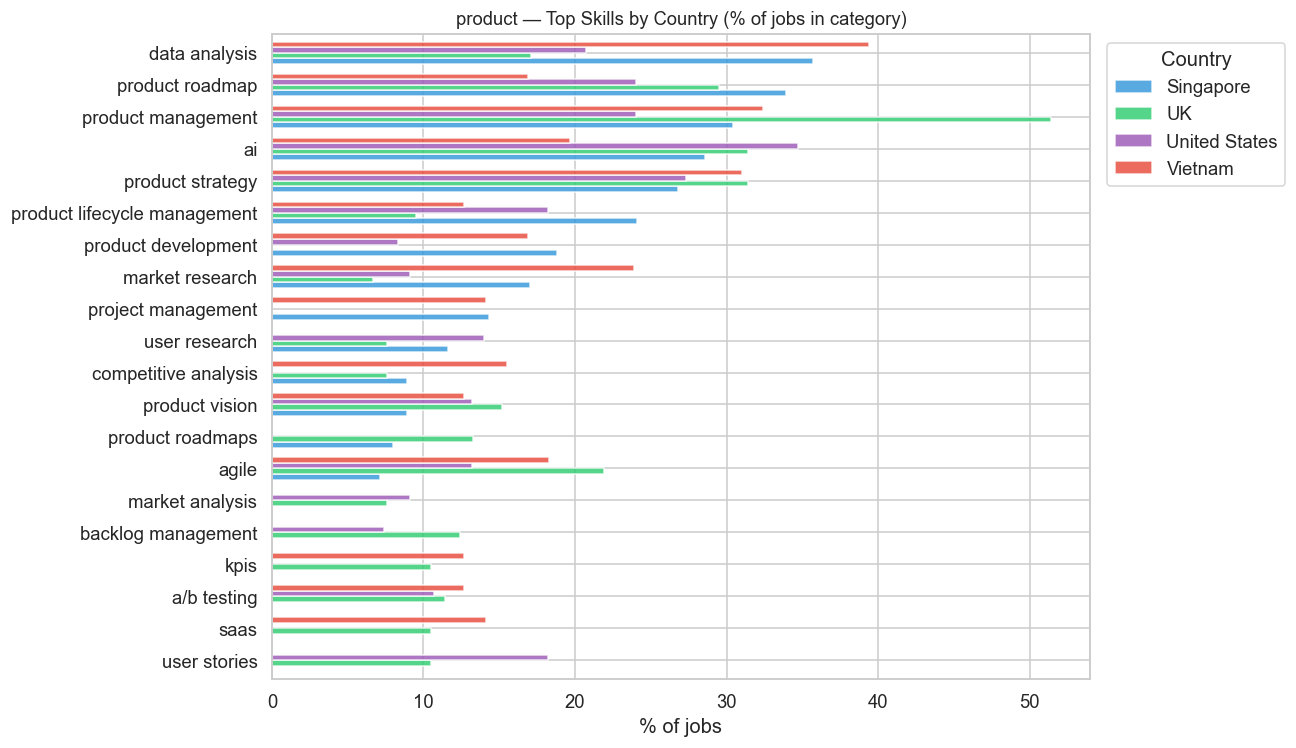

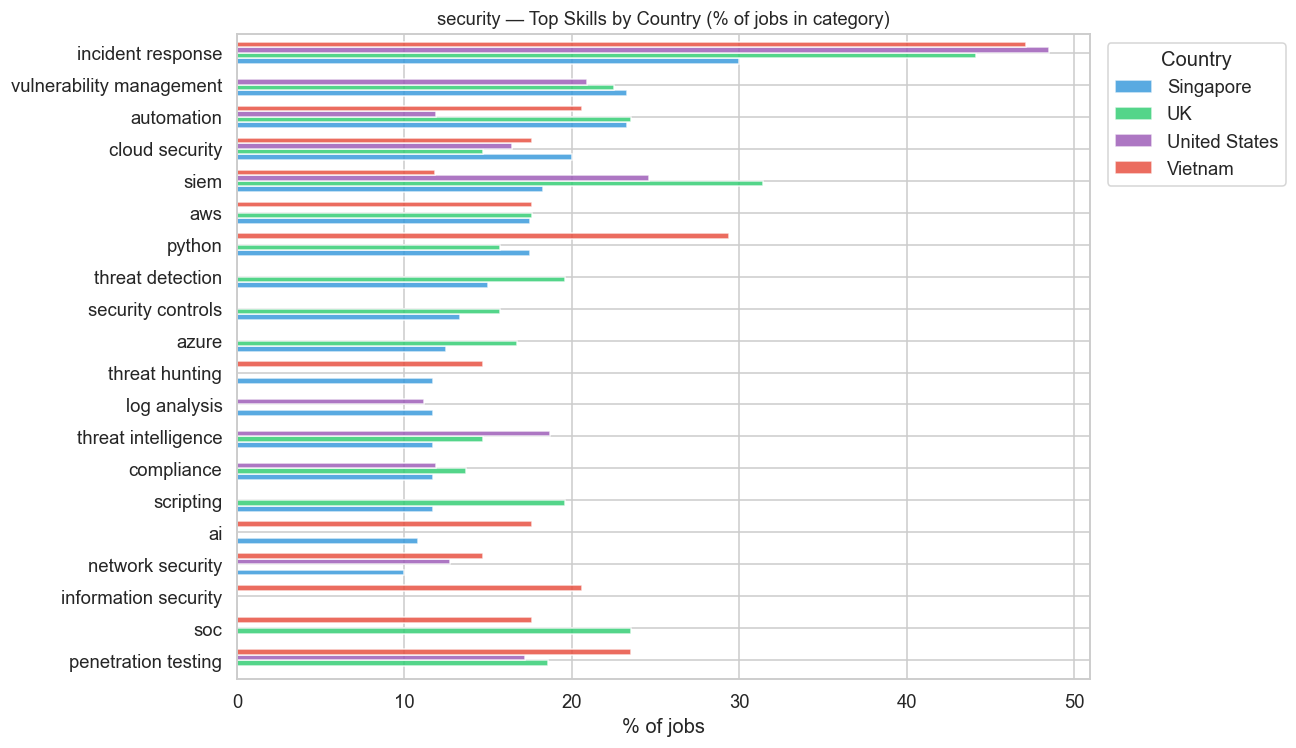

In [18]:
# For top 6 categories, compare skill demand (mention rate %) across countries
top_cats = all_df['job_category'].value_counts().head(6).index.tolist()

for cat in top_cats:
    cat_data = {}
    for country, d in dfs.items():
        sub = d[d['job_category'] == cat]
        if len(sub) < 5:
            continue
        freq  = Counter(parse_skills(sub['hard_skills']))
        total = len(sub)
        cat_data[country] = {s: round(100 * c / total, 1) for s, c in freq.most_common(20)}

    if not cat_data:
        continue

    # Union of top 15 skills per country for this category
    union_skills = set()
    for d in cat_data.values():
        union_skills.update(list(d.keys())[:15])

    skill_df = pd.DataFrame(
        {skill: {c: cat_data[c].get(skill, 0) for c in cat_data} for skill in union_skills}
    ).T
    skill_df['_mean'] = skill_df.mean(axis=1)
    skill_df = (skill_df.sort_values('_mean', ascending=False)
                        .head(20)
                        .drop('_mean', axis=1))
    if skill_df.empty:
        continue

    fig, ax = plt.subplots(figsize=(12, 7))
    skill_df_plot = skill_df.sort_values(skill_df.columns[0], ascending=True)
    skill_df_plot.plot(kind='barh', ax=ax,
                       color=[COLORS.get(c, 'gray') for c in skill_df_plot.columns],
                       alpha=0.82, width=0.7)
    ax.set_title(f'{cat} — Top Skills by Country (% of jobs in category)', fontsize=12)
    ax.set_xlabel('% of jobs')
    ax.legend(title='Country', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

---
## 6. Skill Vocabulary Overlap (Jaccard)

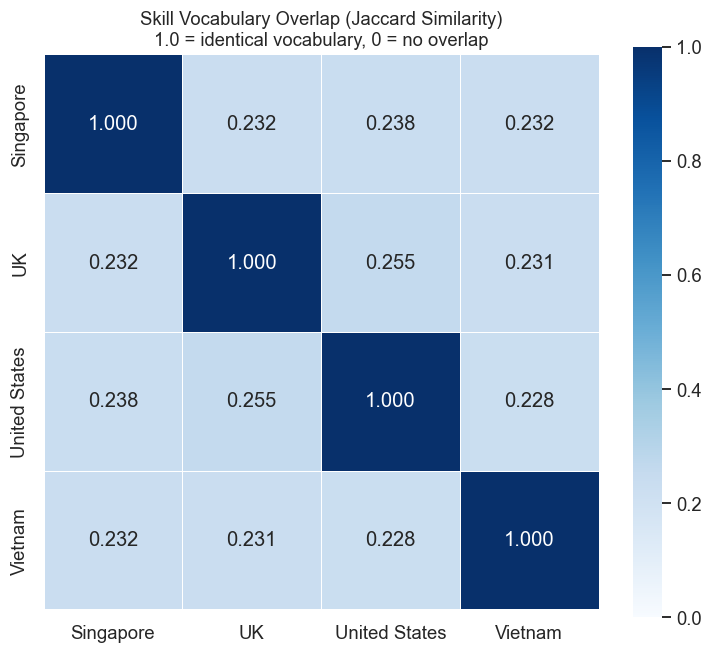


Vocabulary sizes:
  Singapore: 7,166 unique skills
  UK: 5,924 unique skills
  United States: 7,372 unique skills
  Vietnam: 5,579 unique skills


In [19]:
vocab    = {c: set(parse_skills(d['hard_skills'])) for c, d in dfs.items()}
countries = list(dfs.keys())

jac = pd.DataFrame(index=countries, columns=countries, dtype=float)
for c1 in countries:
    for c2 in countries:
        inter = len(vocab[c1] & vocab[c2])
        union = len(vocab[c1] | vocab[c2])
        jac.loc[c1, c2] = round(inter / union, 3) if union > 0 else 0.0

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(jac.astype(float), annot=True, fmt='.3f', cmap='Blues',
            ax=ax, vmin=0, vmax=1, linewidths=0.5, square=True)
ax.set_title('Skill Vocabulary Overlap (Jaccard Similarity)\n1.0 = identical vocabulary, 0 = no overlap', fontsize=12)
plt.tight_layout()
plt.show()

print('\nVocabulary sizes:')
for c, v in vocab.items():
    print(f'  {c}: {len(v):,} unique skills')

---
## 7. Skill Gap — Where Countries Differ Most

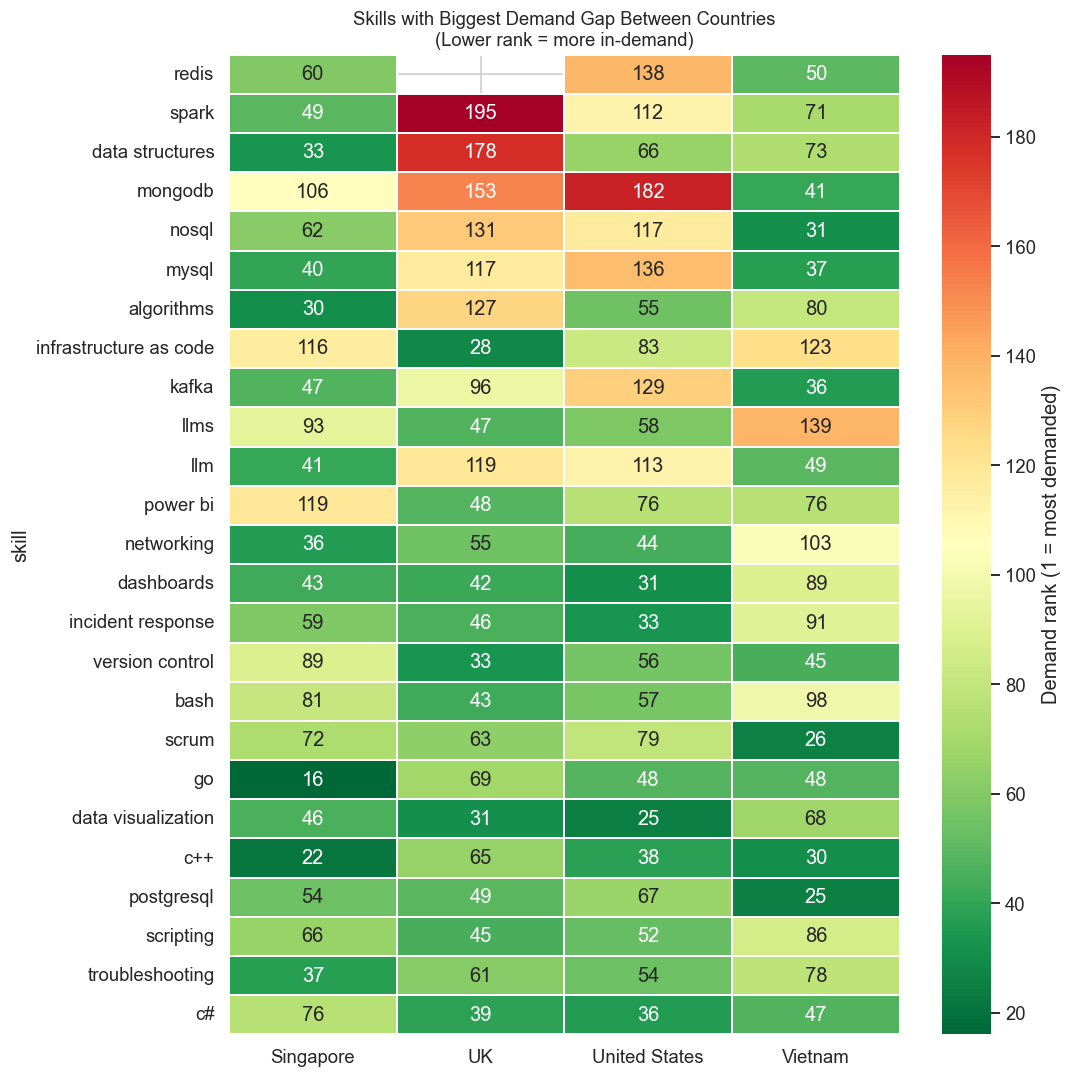


Top 10 skill gaps:
                        Singapore   UK  United States  Vietnam  gap
skill                                                              
redis                          60  200            138       50  150
spark                          49  195            112       71  146
data structures                33  178             66       73  145
mongodb                       106  153            182       41  141
nosql                          62  131            117       31  100
mysql                          40  117            136       37   99
algorithms                     30  127             55       80   97
infrastructure as code        116   28             83      123   95
kafka                          47   96            129       36   93
llms                           93   47             58      139   92


In [20]:
# Rank each skill by frequency per country; find skills with large rank gaps
country_ranks = {}
for country, d in dfs.items():
    freq = Counter(parse_skills(d['hard_skills']))
    country_ranks[country] = {s: i + 1 for i, (s, _) in enumerate(freq.most_common())}

# Candidate skills: top 50 in at least one country
candidates = set()
for d in dfs.values():
    freq = Counter(parse_skills(d['hard_skills']))
    candidates |= {s for s, _ in freq.most_common(50)}

gap_rows = []
for skill in candidates:
    ranks = {c: country_ranks[c].get(skill, 200) for c in dfs}
    gap = max(ranks.values()) - min(ranks.values())
    if gap >= 25:
        gap_rows.append({'skill': skill, **ranks, 'gap': gap})

gap_df = (pd.DataFrame(gap_rows)
            .sort_values('gap', ascending=False)
            .head(25)
            .set_index('skill'))

rank_hm = gap_df[list(dfs.keys())].replace(200, np.nan)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(rank_hm.astype(float), annot=True, fmt='.0f', cmap='RdYlGn_r',
            ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Demand rank (1 = most demanded)'})
ax.set_title('Skills with Biggest Demand Gap Between Countries\n(Lower rank = more in-demand)', fontsize=12)
plt.tight_layout()
plt.show()

print('\nTop 10 skill gaps:')
print(gap_df[list(dfs.keys()) + ['gap']].head(10).to_string())

---
## 8. Soft Skills by Country

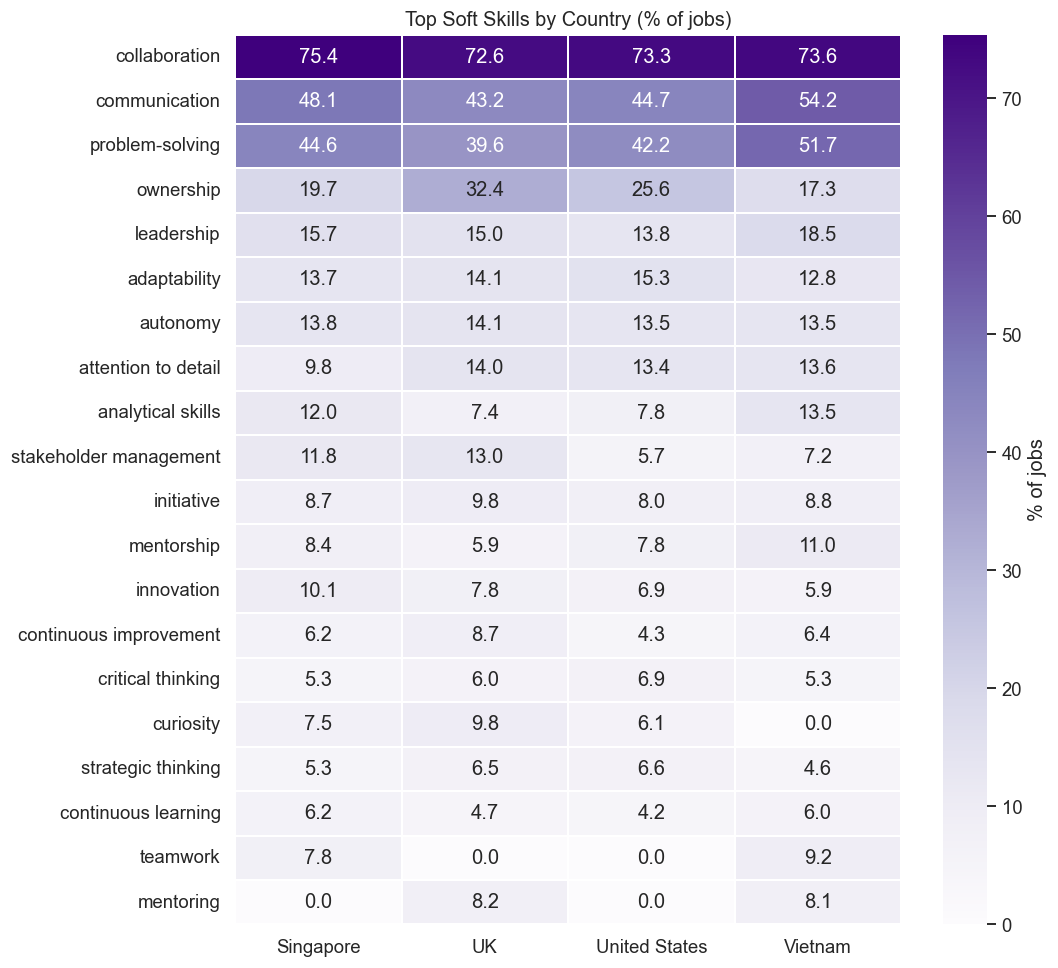

In [21]:
soft_data = {}
for country, d in dfs.items():
    freq  = Counter(parse_skills(d['soft_skills']))
    total = len(d)
    soft_data[country] = {s: round(100 * c / total, 1) for s, c in freq.most_common(20)}

# Union top 20 per country, sorted by global mean
all_soft = set()
for d in soft_data.values():
    all_soft.update(list(d.keys())[:20])

soft_hm = pd.DataFrame({c: {s: soft_data[c].get(s, 0) for s in all_soft} for c in dfs})
soft_hm['_mean'] = soft_hm.mean(axis=1)
soft_hm = soft_hm.sort_values('_mean', ascending=False).head(20).drop('_mean', axis=1)

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(soft_hm, annot=True, fmt='.1f', cmap='Purples',
            ax=ax, linewidths=0.3, cbar_kws={'label': '% of jobs'})
ax.set_title('Top Soft Skills by Country (% of jobs)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 9. Country Skill Uniqueness

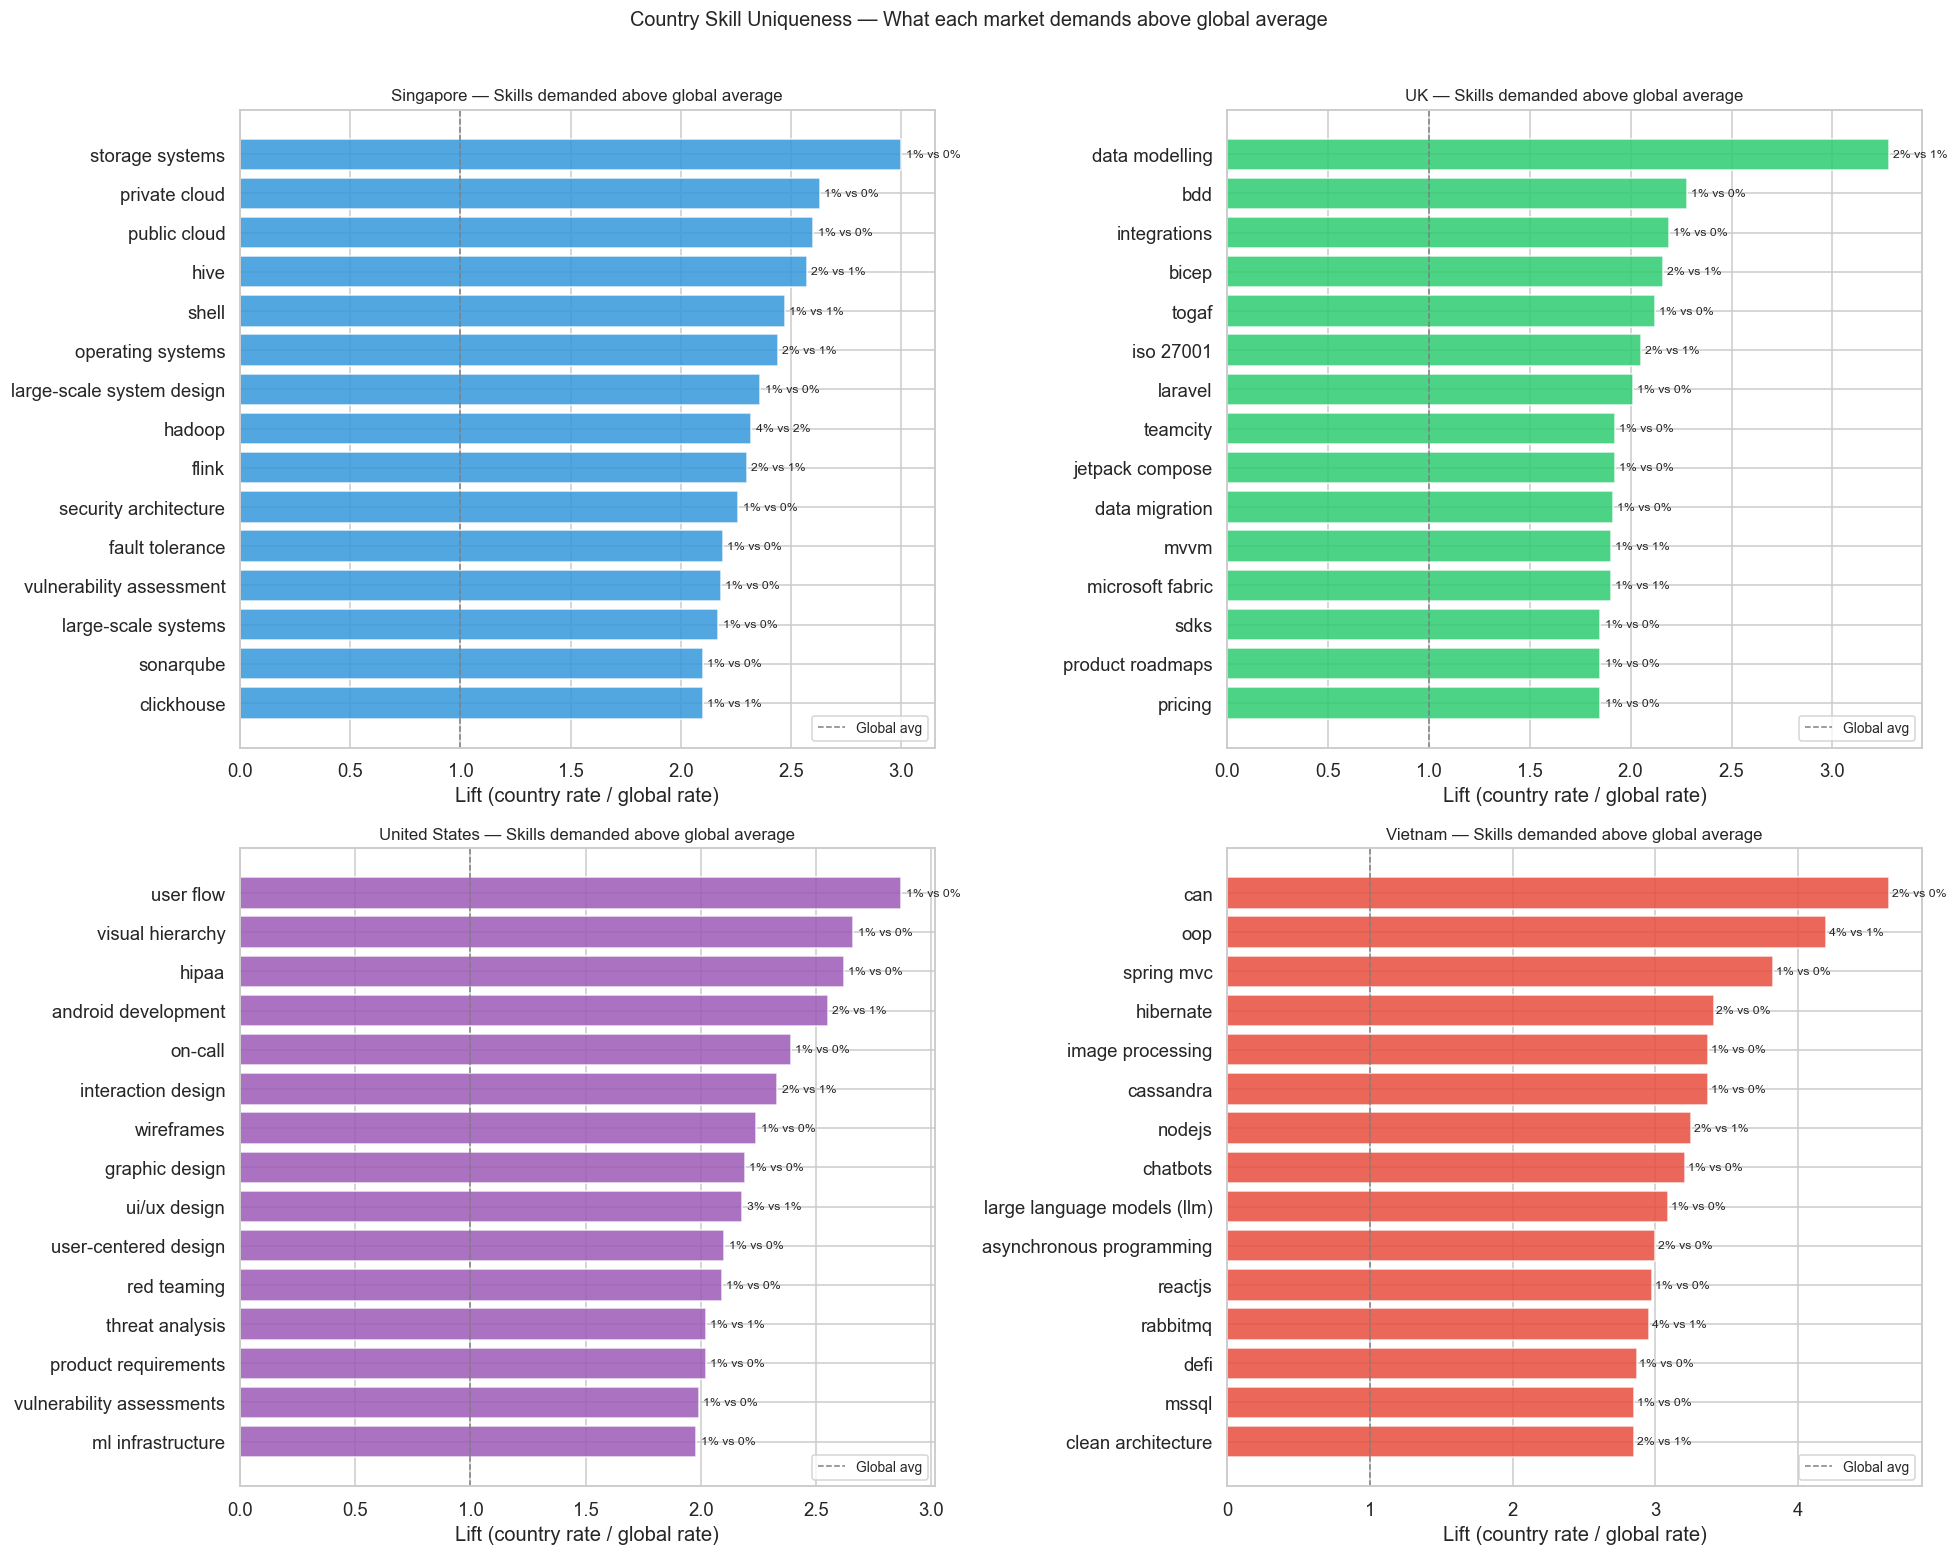

In [22]:
# Lift = country mention rate / global mention rate
# Lift > 1 means that country demands this skill MORE than the global average
MIN_GLOBAL_FREQ = 20

global_freq  = Counter(parse_skills(all_df["hard_skills"]))
global_total = len(all_df)
global_rate  = {s: c / global_total for s, c in global_freq.items()
                if c >= MIN_GLOBAL_FREQ}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (country, d) in enumerate(dfs.items()):
    c_freq  = skill_freq(d["hard_skills"])
    c_total = len(d)

    lift_rows = []
    for skill, g_rate in global_rate.items():
        c_rate = c_freq.get(skill, 0) / c_total
        lift   = c_rate / g_rate if g_rate > 0 else 0
        lift_rows.append({"skill": skill, "lift": round(lift, 2),
                          "country_pct": round(c_rate * 100, 1),
                          "global_pct":  round(g_rate * 100, 1)})

    top = (pd.DataFrame(lift_rows)
             .sort_values("lift", ascending=False)
             .head(15)
             .sort_values("lift", ascending=True))

    ax = axes[i]
    bars = ax.barh(top["skill"], top["lift"], color=COLORS[country], alpha=0.85)
    ax.axvline(x=1.0, color="gray", linestyle="--", linewidth=1, label="Global avg")
    ax.set_title(f"{country} — Skills demanded above global average", fontsize=11)
    ax.set_xlabel("Lift (country rate / global rate)")
    for bar, c_pct, g_pct in zip(bars, top["country_pct"], top["global_pct"]):
        ax.text(bar.get_width() + 0.02,
                bar.get_y() + bar.get_height() / 2,
                f"{c_pct:.0f}% vs {g_pct:.0f}%",
                va="center", fontsize=8)
    ax.legend(fontsize=9)

plt.suptitle("Country Skill Uniqueness — What each market demands above global average",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()